In [4]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#arranging to diplay all rows and columns to have visibility on data set

pd.set_option('display.max_rows',500)
pd.set_option('display.max_columns',500)
pd.set_option('display.width',1000)
pd.set_option('display.expand_frame_repr',False)

In [6]:
#ignore warning
import warnings
warnings.filterwarnings("ignore")

In [7]:
import os 
print("Current folder:",)
print(os.getcwd())
print("Files in folder:")
print(os.listdir())

Current folder:
C:\Users\Mayuchevva
Files in folder:
['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2c94df0a-2652-11f0-8b4c-58020583a087}.TM.blf', 'NTUSER.DAT{2c94df0a-2652-11f0-8b4c-58020583a087}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2c94df0a-2652-11f0-8b4c-58020583a087}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'pd.read_csv()', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'swiggy.ipynb', 'swiggy_instamart.csv', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Videos']


In [8]:
df = pd.read_csv("swiggy_instamart.csv")

In [9]:
df.head()

,order_id,customer_id,order_date,order_time,city,area,product_id,product_name,brand,category,sub_category,quantity,price,mrp,discount_pct,final_price,payment_mode,delivery_time_min,rating,stock_status,order_status
0,O1001,C501,2026-05-01,19:12,Mumbai,Andheri,P001,Amul Taaza Milk,Amul,Dairy,Milk,2,28,30,7,56,UPI,14,4.6,In Stock,Delivered
1,O1002,C502,2026-05-01,20:05,Mumbai,Bandra,P002,Britannia Bread,Britannia,Bakery,Bread,1,40,45,11,40,Card,12,4.4,In Stock,Delivered
2,O1003,C503,2026-05-02,18:40,Mumbai,Thane,P003,Lays Classic Chips,Lays,Snacks,Chips,3,20,24,17,60,Cash,16,4.2,In Stock,Delivered
3,O1004,C504,2026-05-02,21:15,Mumbai,Malad,P004,Tata Salt,Tata,Staples,Salt,1,22,25,12,22,UPI,18,4.7,In Stock,Delivered
4,O1005,C505,2026-05-03,08:55,Mumbai,Powai,P005,Maggi 2-Minute Noodles,Maggi,Instant Food,Noodles,4,14,15,7,56,UPI,11,4.8,Low Stock,Delivered


In [10]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(20, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           20 non-null     object 
 1   customer_id        20 non-null     object 
 2   order_date         20 non-null     object 
 3   order_time         20 non-null     object 
 4   city               20 non-null     object 
 5   area               20 non-null     object 
 6   product_id         20 non-null     object 
 7   product_name       20 non-null     object 
 8   brand              20 non-null     object 
 9   category           20 non-null     object 
 10  sub_category       20 non-null     object 
 11  quantity           20 non-null     int64  
 12  price              20 non-null     int64  
 13  mrp                20 non-null     int64  
 14  discount_pct       20 non-null     int64  
 15  final_price        20 non-null     int64  
 16  payment_mode       

In [11]:
df = df.drop_duplicates()
df["order_date"] = pd.to_datetime(df["order_date"])
df["delivery_time_min"] = pd.to_numeric(df["delivery_time_min"], errors="coerce")
df["final_price"] = pd.to_numeric(df['final_price'], errors='coerce')
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [12]:
df.describe()

,order_date,quantity,price,mrp,discount_pct,final_price,delivery_time_min,rating
count,20,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.00000
mean,2026-05-05 12:00:00,1.650000,77.450000,86.050000,10.700000,97.60000,16.450000,4.39500
min,2026-05-01 00:00:00,1.000000,10.000000,12.000000,5.000000,20.00000,11.000000,4.00000
25%,2026-05-03 00:00:00,1.000000,29.500000,33.750000,8.000000,55.75000,13.750000,4.20000
50%,2026-05-05 12:00:00,1.000000,53.500000,57.500000,10.500000,80.50000,16.000000,4.40000
75%,2026-05-08 00:00:00,2.000000,112.500000,123.750000,12.500000,126.25000,18.250000,4.60000
max,2026-05-10 00:00:00,4.000000,255.000000,280.000000,20.000000,255.00000,24.000000,4.80000
std,NaN,0.875094,65.976451,72.494265,4.040584,61.86692,3.677456,0.22589


In [13]:
df["order_hour"] = pd.to_datetime(df["order_time"], format="%H:%M").dt.hour
df["day_name"] = df["order_date"].dt.day_name()
df["revenue"] =df["final_price"]
df["delivery_bucket"] = pd.cut(
    df["delivery_time_min"],
    bins=[0,10,15,20,30,100],
    labels=["0-10","11-15","16-20","21-30","30+"])

In [14]:
df.describe()

,order_date,quantity,price,mrp,discount_pct,final_price,delivery_time_min,rating,order_hour,revenue
count,20,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.00000,20.000000,20.00000
mean,2026-05-05 12:00:00,1.650000,77.450000,86.050000,10.700000,97.60000,16.450000,4.39500,16.700000,97.60000
min,2026-05-01 00:00:00,1.000000,10.000000,12.000000,5.000000,20.00000,11.000000,4.00000,8.000000,20.00000
25%,2026-05-03 00:00:00,1.000000,29.500000,33.750000,8.000000,55.75000,13.750000,4.20000,14.750000,55.75000
50%,2026-05-05 12:00:00,1.000000,53.500000,57.500000,10.500000,80.50000,16.000000,4.40000,18.500000,80.50000
75%,2026-05-08 00:00:00,2.000000,112.500000,123.750000,12.500000,126.25000,18.250000,4.60000,20.000000,126.25000
max,2026-05-10 00:00:00,4.000000,255.000000,280.000000,20.000000,255.00000,24.000000,4.80000,22.000000,255.00000
std,NaN,0.875094,65.976451,72.494265,4.040584,61.86692,3.677456,0.22589,4.725073,61.86692


In [15]:
total_orders = df["order_id"].nunique()
total_revenue = df["revenue"].sum()
avg_delivery = df["delivery_time_min"].mean()

category_sales = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
top_products = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10)
payment_usage = df["payment_mode"].value_counts()

In [16]:
df.describe()

,order_date,quantity,price,mrp,discount_pct,final_price,delivery_time_min,rating,order_hour,revenue
count,20,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.00000,20.000000,20.00000
mean,2026-05-05 12:00:00,1.650000,77.450000,86.050000,10.700000,97.60000,16.450000,4.39500,16.700000,97.60000
min,2026-05-01 00:00:00,1.000000,10.000000,12.000000,5.000000,20.00000,11.000000,4.00000,8.000000,20.00000
25%,2026-05-03 00:00:00,1.000000,29.500000,33.750000,8.000000,55.75000,13.750000,4.20000,14.750000,55.75000
50%,2026-05-05 12:00:00,1.000000,53.500000,57.500000,10.500000,80.50000,16.000000,4.40000,18.500000,80.50000
75%,2026-05-08 00:00:00,2.000000,112.500000,123.750000,12.500000,126.25000,18.250000,4.60000,20.000000,126.25000
max,2026-05-10 00:00:00,4.000000,255.000000,280.000000,20.000000,255.00000,24.000000,4.80000,22.000000,255.00000
std,NaN,0.875094,65.976451,72.494265,4.040584,61.86692,3.677456,0.22589,4.725073,61.86692


In [17]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           20 non-null     object        
 1   customer_id        20 non-null     object        
 2   order_date         20 non-null     datetime64[ns]
 3   order_time         20 non-null     object        
 4   city               20 non-null     object        
 5   area               20 non-null     object        
 6   product_id         20 non-null     object        
 7   product_name       20 non-null     object        
 8   brand              20 non-null     object        
 9   category           20 non-null     object        
 10  sub_category       20 non-null     object        
 11  quantity           20 non-null     int64         
 12  price              20 non-null     int64         
 13  mrp                20 non-null     int64         
 14  discount_pct

order_id             0
customer_id          0
order_date           0
order_time           0
city                 0
area                 0
product_id           0
product_name         0
brand                0
category             0
sub_category         0
quantity             0
price                0
mrp                  0
discount_pct         0
final_price          0
payment_mode         0
delivery_time_min    0
rating               0
stock_status         0
order_status         0
order_hour           0
day_name             0
revenue              0
delivery_bucket      0
dtype: int64

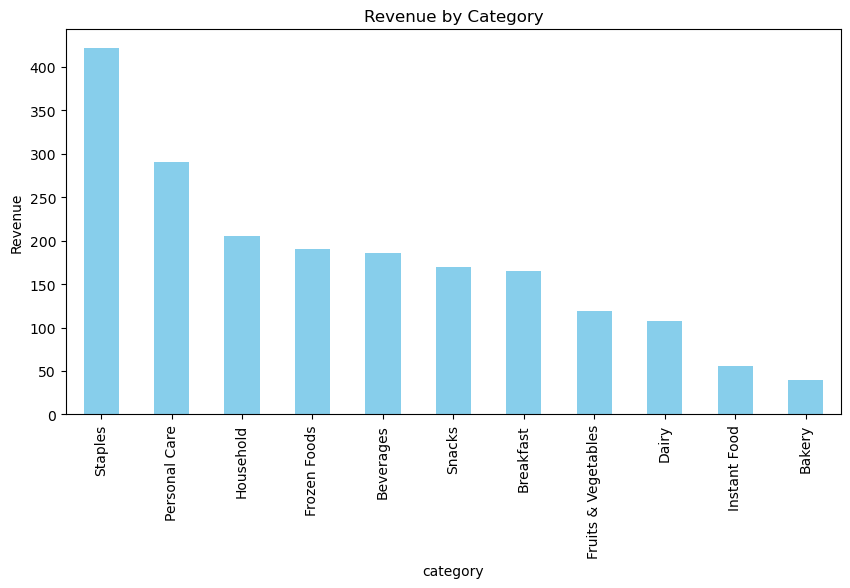

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
category_sales.plot(kind="bar", color="skyblue")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

In [19]:
category_sales = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
category_sales

category
Staples                422
Personal Care          291
Household              205
Frozen Foods           190
Beverages              186
Snacks                 170
Breakfast              165
Fruits & Vegetables    119
Dairy                  108
Instant Food            56
Bakery                  40
Name: revenue, dtype: int64

In [20]:
category_sales.head(5)

category
Staples          422
Personal Care    291
Household        205
Frozen Foods     190
Beverages        186
Name: revenue, dtype: int64

In [21]:
#Product analysis
top_products = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10)
top_products

product_name
Maggi 2-Minute Noodles    4
Good Day Cookies          3
Lays Classic Chips        3
Onion 1kg                 2
Amul Taaza Milk           2
Coca-Cola 750ml           2
Colgate Toothpaste        2
Parle-G Biscuits          2
Frozen Peas 500g          2
Tata Salt                 1
Name: quantity, dtype: int64

In [22]:
#Order time analysis
hourly_orders = df.groupby("order_hour")["order_id"].count()
hourly_orders

order_hour
8     2
9     1
10    1
11    1
16    1
17    2
18    2
19    3
20    3
21    3
22    1
Name: order_id, dtype: int64

In [23]:
#Delivery analysis
area_delivery = df.groupby("area")["delivery_time_min"].mean().sort_values(ascending=False)
area_delivery

area
Kukatpally     24.0
Koramangala    23.0
Indiranagar    21.0
Chembur        20.0
Borivali       19.0
HSR Layout     18.0
Hinjewadi      18.0
Malad          18.0
Dadar          17.0
Thane          16.0
Madhapur       16.0
Gachibowli     15.0
Goregaon       15.0
Whitefield     14.0
Andheri        14.0
Kurla          13.0
Ameerpet       13.0
Jayanagar      12.0
Bandra         12.0
Powai          11.0
Name: delivery_time_min, dtype: float64

In [24]:
#Payment analysis
payment_mode_count = df["payment_mode"].value_counts()
payment_mode_count


payment_mode
UPI       9
Card      6
Cash      3
Wallet    2
Name: count, dtype: int64

In [25]:
#Order state analysis
df["order_status"].value_counts()

order_status
Delivered    18
Delayed       2
Name: count, dtype: int64

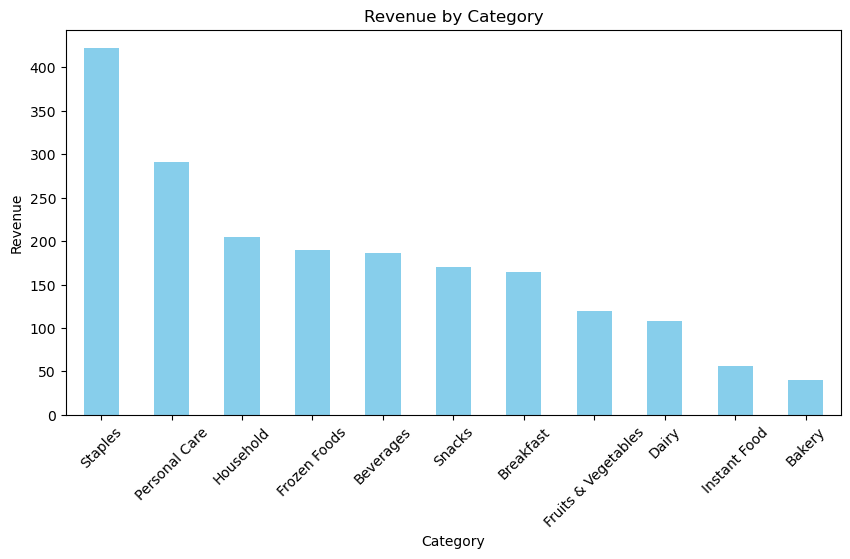

In [26]:
#Revenue by Category
plt.figure(figsize=(10,5))
category_sales.plot(kind="bar", color="skyblue")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

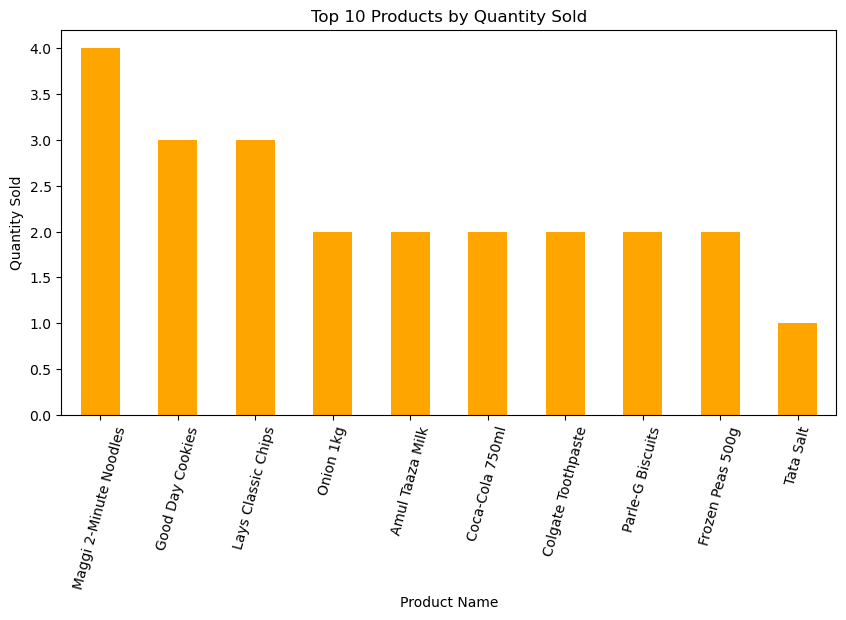

In [27]:
#Top order products
plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color="orange")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.show()

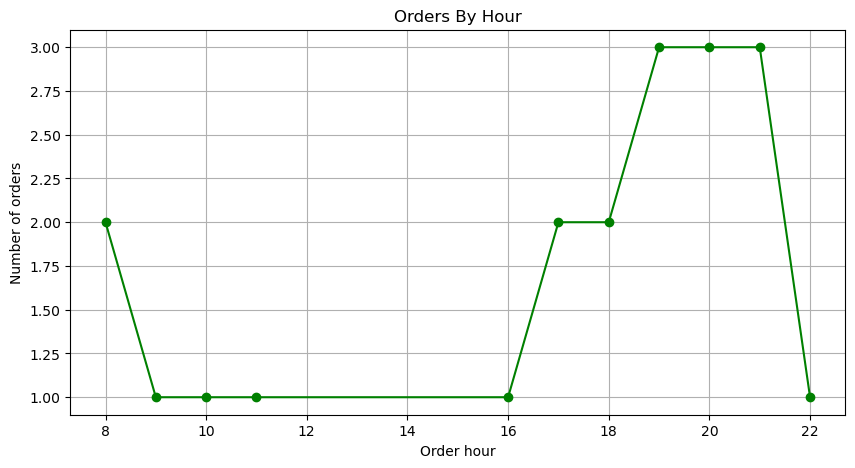

In [28]:
#Peak ordering Hour
plt.figure(figsize=(10,5))
hourly_orders.plot(kind="line", marker="o", color="green")
plt.title("Orders By Hour")
plt.xlabel("Order hour")
plt.ylabel("Number of orders")
plt.grid(True)
plt.show()


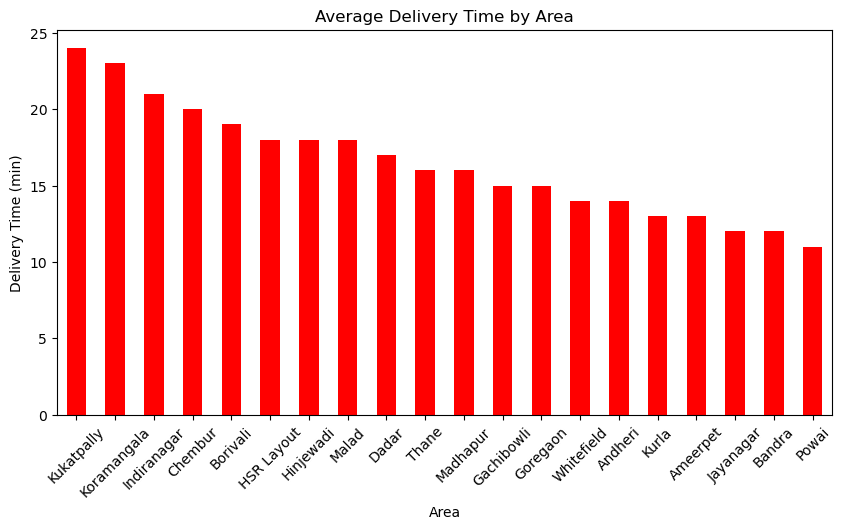

In [29]:
#Average delivery time by area
plt.figure(figsize=(10,5))
area_delivery.plot(kind="bar", color="red")
plt.title("Average Delivery Time by Area")
plt.xlabel("Area")
plt.ylabel("Delivery Time (min)")
plt.xticks(rotation=45)
plt.show()

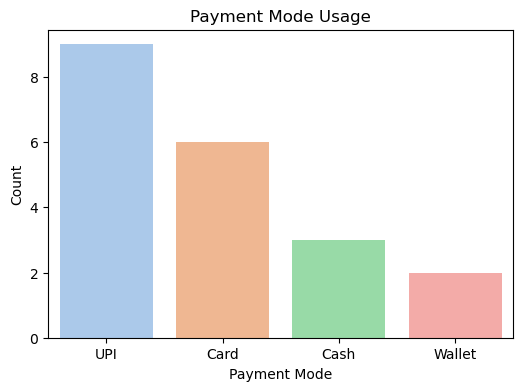

In [30]:
#Payment Mode Chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="payment_mode", palette="pastel")
plt.title("Payment Mode Usage")
plt.xlabel("Payment Mode")
plt.ylabel("Count")
plt.show()

In [31]:
#summary
print("----- PROJECT SUMMARY -----")
print("Total Orders:", df["order_id"].nunique())
print("Total Revenue:", df["revenue"].sum())
print("Top Category:", category_sales.idxmax())
print("Average Delivery Time:", round(df["delivery_time_min"].mean(), 2))
print("Most Used Payment Mode:", df["payment_mode"].mode()[0])

----- PROJECT SUMMARY -----
Total Orders: 20
Total Revenue: 1952
Top Category: Staples
Average Delivery Time: 16.45
Most Used Payment Mode: UPI
